# GLOF Multi-Sensor Glacial Lake EDA

**Exploratory Data Analysis** of the merged monthly multi-sensor time series across 494 glacial lakes in Nepal (2015–2025).

**Dataset**: master_multisensor_merged.csv  
**Rows**: 65,208 (494 lakes × 132 months)  
**Columns**: 22 (GL_ID, date, year, month + 5 sensor suites)  
**Purpose**: Characterize data quality, seasonal patterns, and anomalies in preparation for autoencoder-based anomaly detection and hazard assessment.

## 0. Setup

**Why this matters**: A robust EDA foundation ensures correct data loading, proper date parsing, consistent visualization styling, and reproducible results. We standardize fonts and plotting options here to maintain publication-quality figures throughout.

In [2]:
# File path (change as needed)
DATA_PATH = '../data/processed/master_multisensor_merged.csv'

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Seaborn theme with consistent styling
# NOTE: sns.set_theme() resets font.family to 'sans-serif' internally, so it
# must be called BEFORE the font rcParams below -- otherwise it silently
# overrides them and every plot renders in the default sans-serif font
# instead of Times New Roman.
sns.set_theme(style="whitegrid")
color_palette = sns.color_palette("husl", 8)

# Set font globally (must come after sns.set_theme, see note above)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Create output directory for figures
output_dir = Path('../outputs/figures')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir}")


Output directory: ..\outputs\figures


In [3]:
# Load data
df = pd.read_csv(DATA_PATH)

# Parse date as datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by GL_ID and date for temporal consistency
df = df.sort_values(['GL_ID', 'date']).reset_index(drop=True)

print("\n" + "="*70)
print("DATASET LOADED")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique lakes (GL_ID): {df['GL_ID'].nunique()}")
print(f"Months per lake: {df.groupby('GL_ID').size().mode().values[0]}")


DATASET LOADED

Shape: (65208, 22)
Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Unique lakes (GL_ID): 494
Months per lake: 132


In [4]:
# Display data types and basic info
print("\nData Types:")
print(df.dtypes)

print("\n" + "="*70)
print("BASIC STATISTICS")
print("="*70)
print(df.describe())


Data Types:
GL_ID                           object
date                    datetime64[ns]
year                             int64
month                            int64
ERA5_temp_K                    float64
ERA5_temp_C                    float64
GPM_Precipitation_mm           float64
GPM_Scan_Count                   int64
LST_Day_C                      float64
LST_Night_C                    float64
LST_Scan_Count                   int64
S1_observations                  int64
VV_mean                        float64
VV_median                      float64
VV_stdDev                      float64
VH_mean                        float64
VH_median                      float64
VH_stdDev                      float64
angle_mean                     float64
S2_observations                  int64
S2_NDWI_mean                   float64
S2_water_area_km2              float64
dtype: object

BASIC STATISTICS
                                date          year         month  \
count                        

In [5]:
# Missing value counts
print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Count': missing_counts.values,
    'Percentage': missing_pct.values
})
print(missing_df.to_string(index=False))


MISSING VALUES
              Column  Count  Percentage
        S2_NDWI_mean  30803       47.24
           VH_median   8228       12.62
           VV_median   8228       12.62
           VV_stdDev   8228       12.62
             VV_mean   8228       12.62
             VH_mean   8228       12.62
           VH_stdDev   8228       12.62
          angle_mean   8199       12.57
         ERA5_temp_C      0        0.00
         ERA5_temp_K      0        0.00
                date      0        0.00
               GL_ID      0        0.00
               month      0        0.00
                year      0        0.00
      LST_Scan_Count      0        0.00
     S1_observations      0        0.00
           LST_Day_C      0        0.00
         LST_Night_C      0        0.00
      GPM_Scan_Count      0        0.00
GPM_Precipitation_mm      0        0.00
     S2_observations      0        0.00
   S2_water_area_km2      0        0.00


---

## 1. Missingness Analysis

**Why this matters**: Missingness patterns reveal sensor limitations (cloud cover, SAR revisit gaps), seasonal acquisition windows, and data quality issues. Understanding these patterns is essential for deciding imputation strategies before feeding data into the autoencoder for anomaly detection.

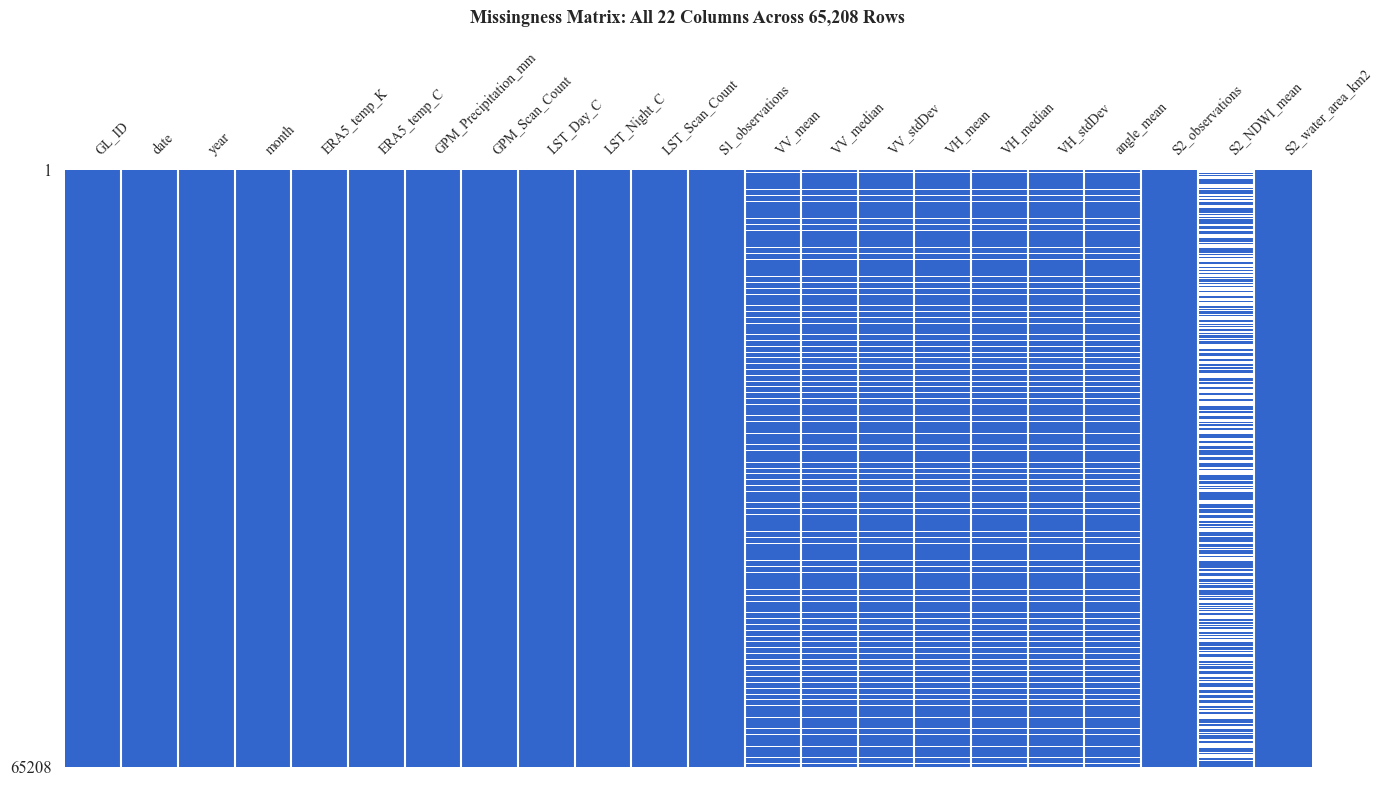

In [6]:
# Missingness matrix visualization
fig, ax = plt.subplots(figsize=(14, 8))
msno.matrix(df, ax=ax, sparkline=False, fontsize=10, color=(0.2, 0.4, 0.8))
plt.title('Missingness Matrix: All 22 Columns Across 65,208 Rows', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(output_dir / '01_missingness_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

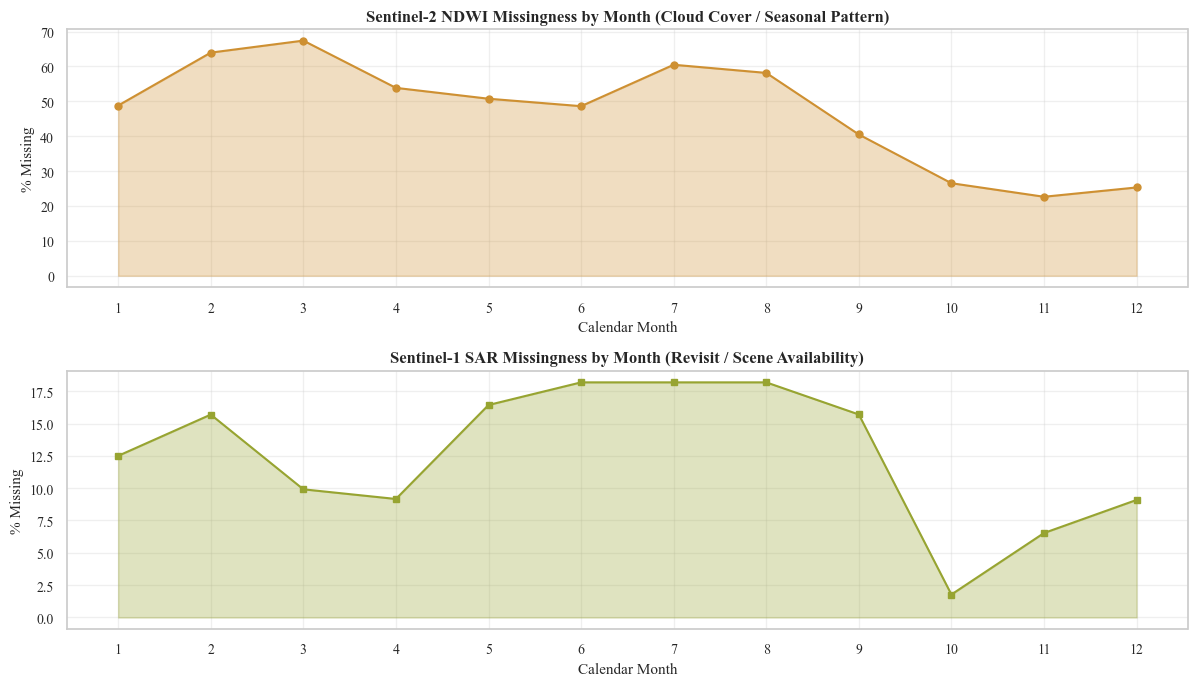


Peak S2 missingness month: 3 (67.4%)
Peak SAR missingness month: 6 (18.2%)


In [7]:
# Seasonal missingness pattern: group by month, compute % missing for S2_NDWI_mean and SAR columns

sar_cols = ['VV_mean', 'VV_median', 'VV_stdDev',
            'VH_mean', 'VH_median', 'VH_stdDev', 'angle_mean']

seasonal_missing = df.groupby('month')[['S2_NDWI_mean'] + sar_cols].apply(
    lambda x: (x.isnull().sum() / len(x) * 100)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# S2_NDWI_mean seasonal pattern
ax1.plot(
    seasonal_missing.index,
    seasonal_missing['S2_NDWI_mean'],
    marker='o',
    markersize=5,
    linewidth=1.5,
    color=color_palette[1],
    label='S2_NDWI_mean'
)

ax1.fill_between(
    seasonal_missing.index,
    seasonal_missing['S2_NDWI_mean'],
    alpha=0.3,
    color=color_palette[1]
)

ax1.set_xlabel('Calendar Month', fontsize=11)
ax1.set_ylabel('% Missing', fontsize=11)
ax1.set_title(
    'Sentinel-2 NDWI Missingness by Month (Cloud Cover / Seasonal Pattern)',
    fontsize=12,
    fontweight='bold'
)
ax1.grid(alpha=0.3)
ax1.set_xticks(range(1, 13))


# SAR columns seasonal pattern (averaged)
sar_avg = seasonal_missing[sar_cols].mean(axis=1)

ax2.plot(
    seasonal_missing.index,
    sar_avg,
    marker='s',
    markersize=5,
    linewidth=1.5,
    color=color_palette[2],
    label='SAR (avg)'
)

ax2.fill_between(
    seasonal_missing.index,
    sar_avg,
    alpha=0.3,
    color=color_palette[2]
)

ax2.set_xlabel('Calendar Month', fontsize=11)
ax2.set_ylabel('% Missing', fontsize=11)
ax2.set_title(
    'Sentinel-1 SAR Missingness by Month (Revisit / Scene Availability)',
    fontsize=12,
    fontweight='bold'
)
ax2.grid(alpha=0.3)
ax2.set_xticks(range(1, 13))

plt.tight_layout()

# Display only — no file saving
plt.show()

print("\nPeak S2 missingness month:",
      seasonal_missing['S2_NDWI_mean'].idxmax(),
      f"({seasonal_missing['S2_NDWI_mean'].max():.1f}%)")

print("Peak SAR missingness month:",
      sar_avg.idxmax(),
      f"({sar_avg.max():.1f}%)")

---

## 2. Univariate Distributions & Outlier Screening

**Why this matters**: Identifying implausible values (e.g., NDWI outside [−1, 1], negative precipitation) is critical for data quality assurance. Outliers and extreme values need to be flagged before autoencoder training to prevent distortion of the learned latent representation.

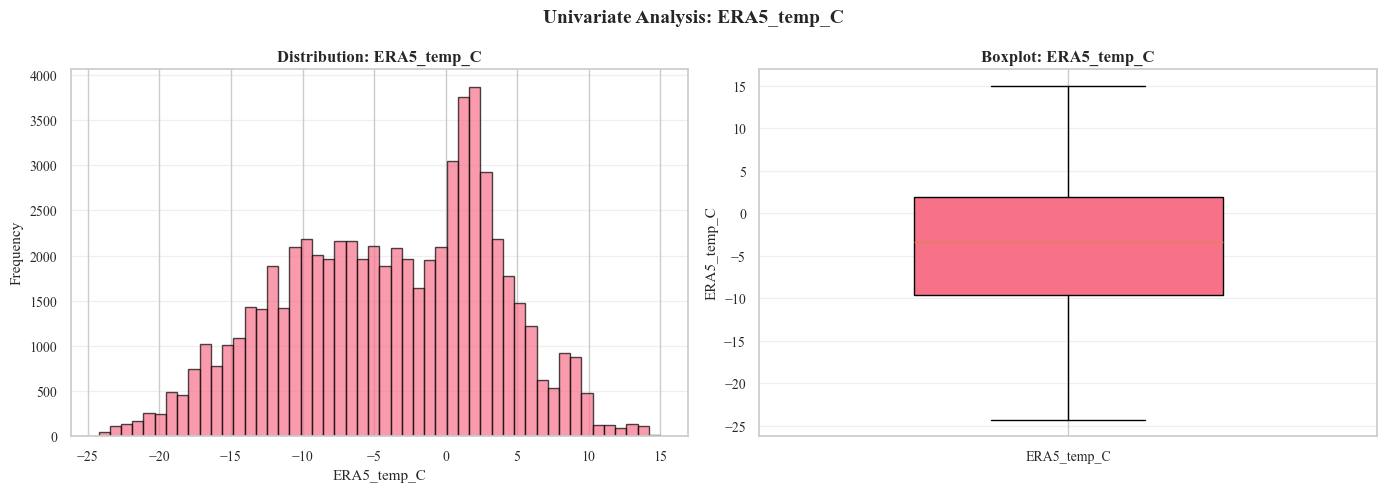

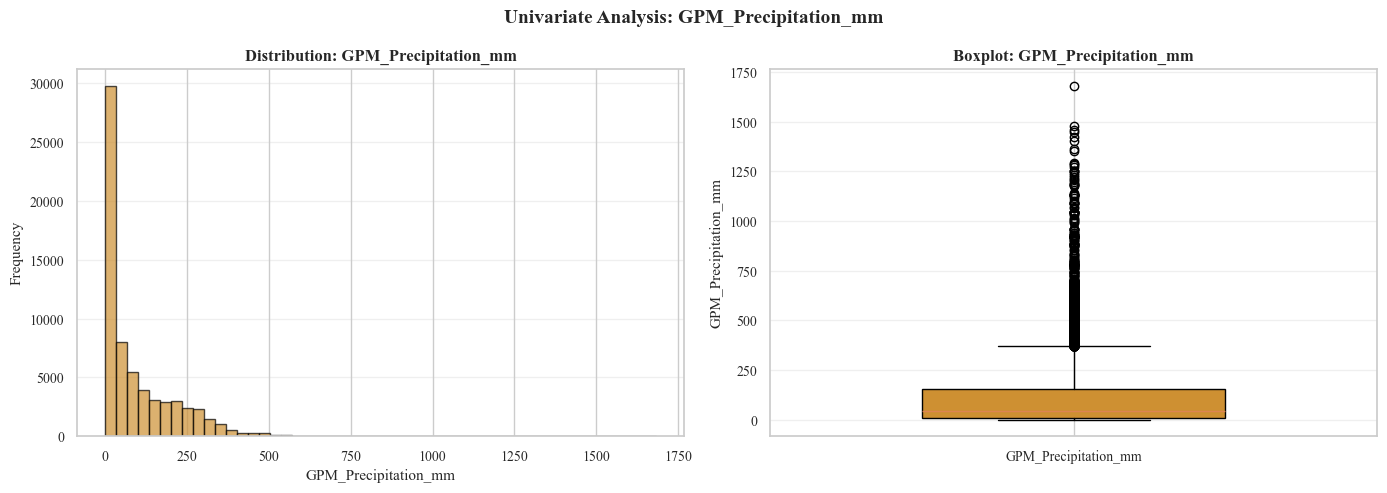

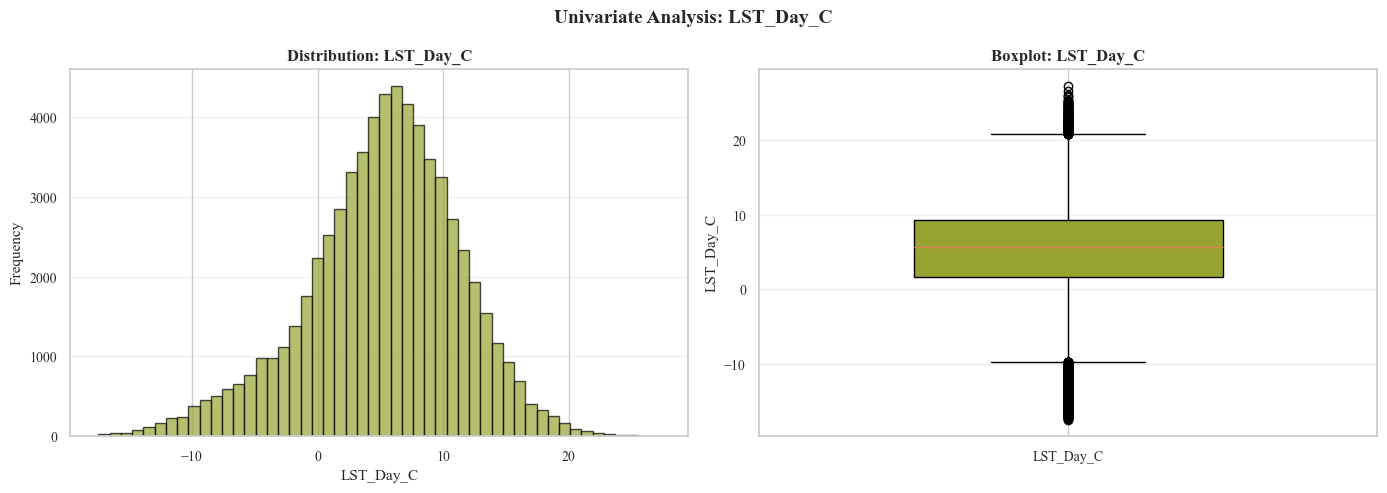

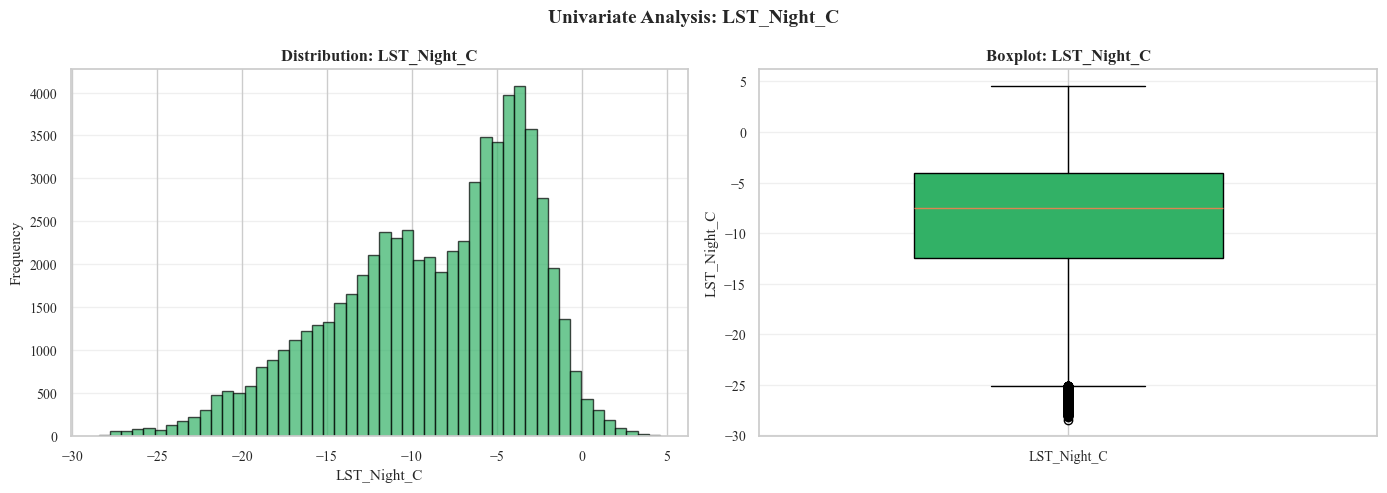

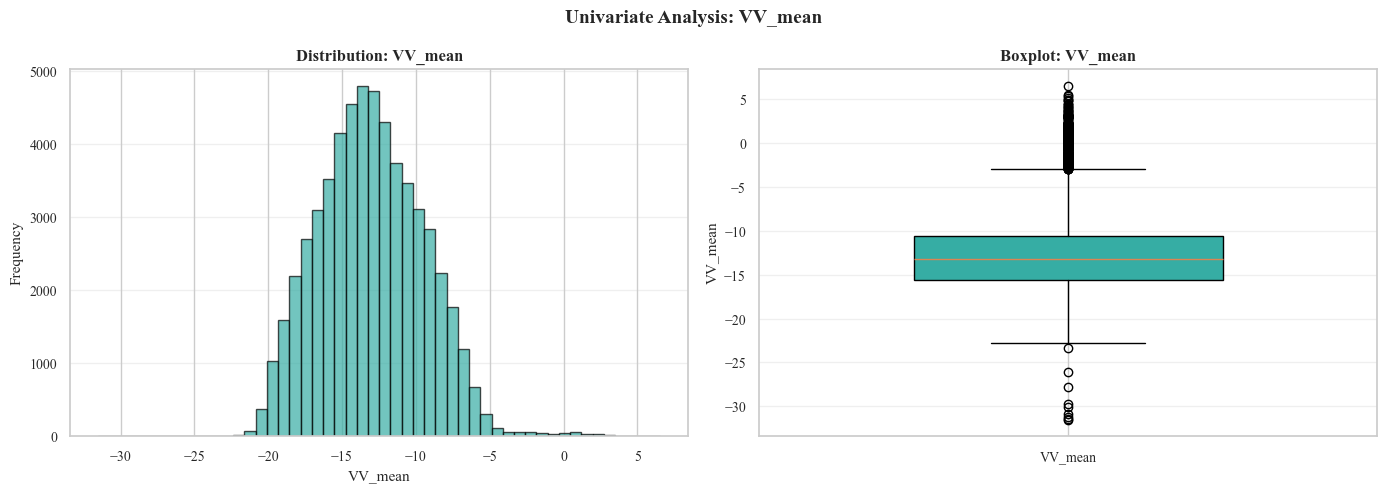

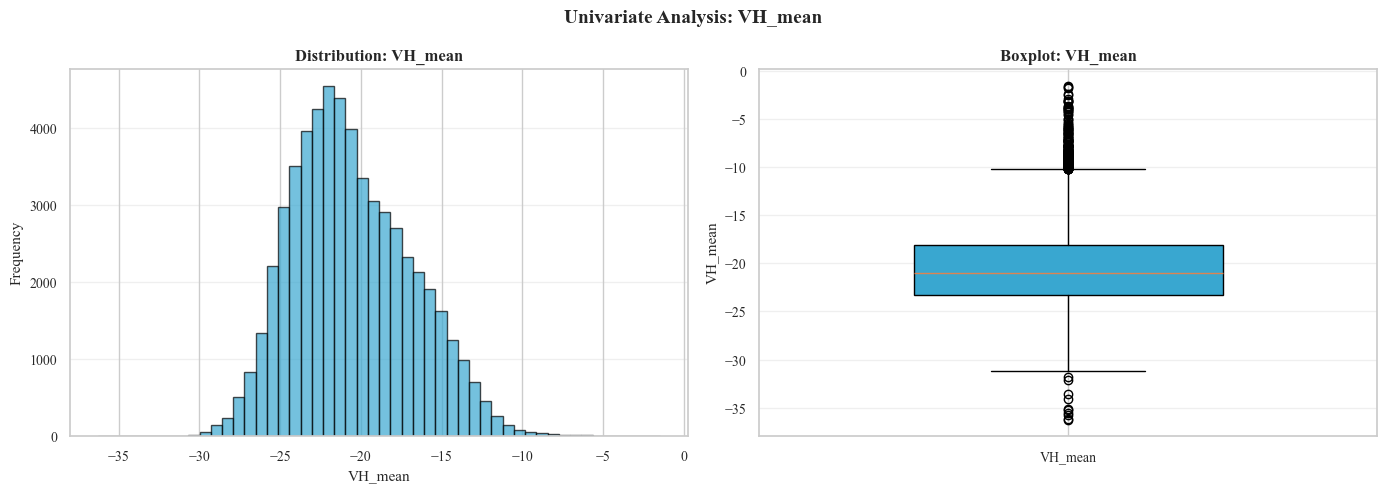

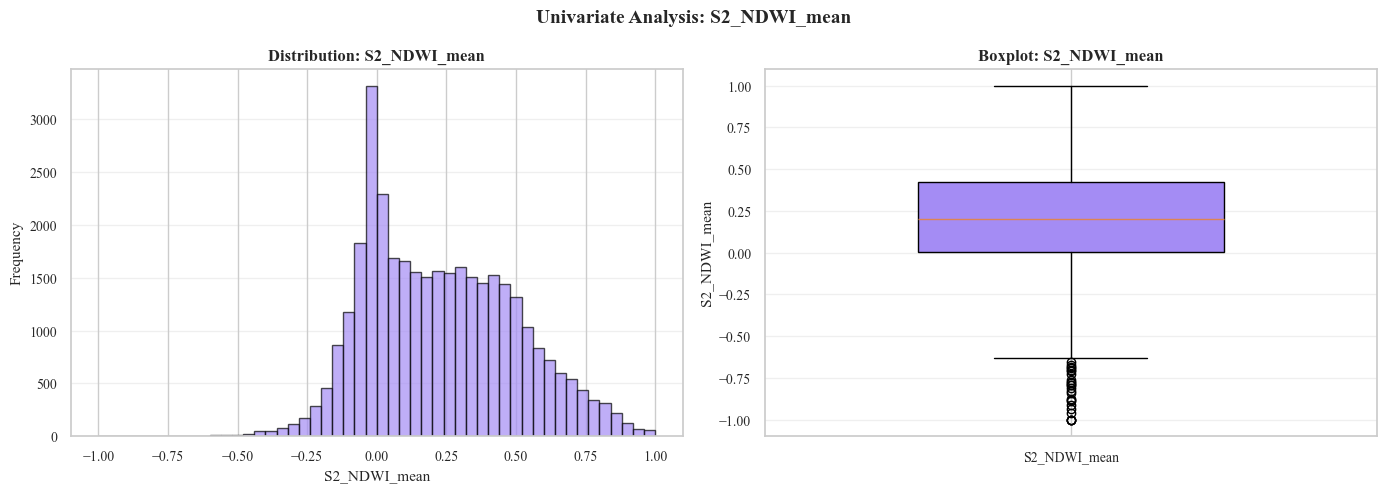

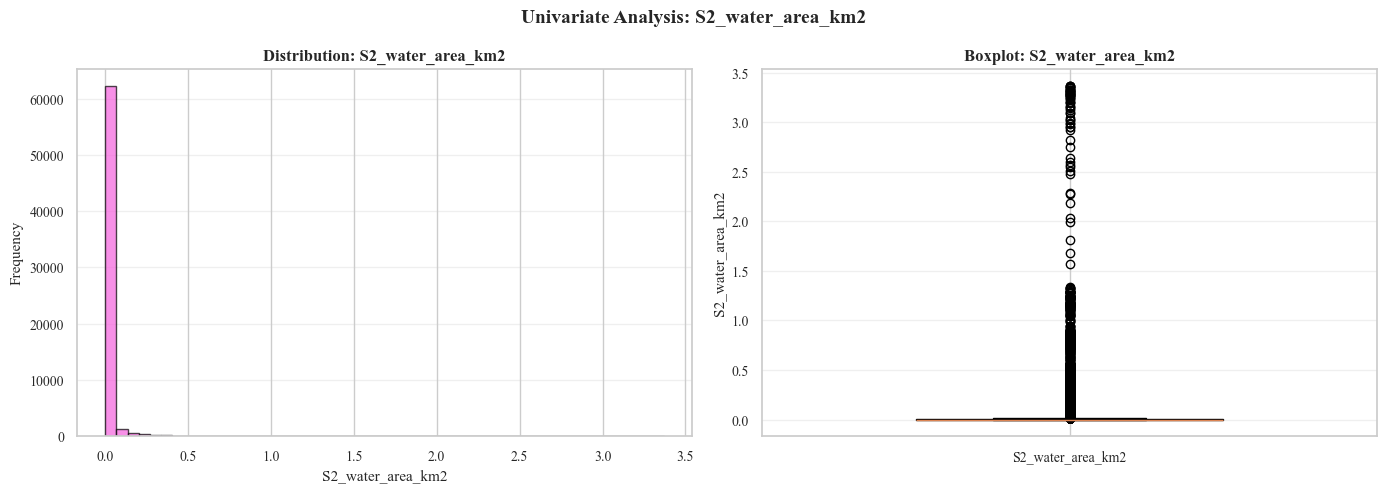

In [8]:
# Define continuous variables for univariate analysis

continuous_vars = [
    'ERA5_temp_C',
    'GPM_Precipitation_mm',
    'LST_Day_C',
    'LST_Night_C',
    'VV_mean',
    'VH_mean',
    'S2_NDWI_mean',
    'S2_water_area_km2'
]

# Create one figure per variable
# Each figure contains: Distribution + Boxplot

for idx, var in enumerate(continuous_vars):

    data = df[var].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --------------------------------------------------
    # Distribution / Histogram
    # --------------------------------------------------

    axes[0].hist(
        data,
        bins=50,
        color=color_palette[idx % len(color_palette)],
        edgecolor='black',
        alpha=0.7
    )

    axes[0].set_xlabel(var, fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)

    axes[0].set_title(
        f'Distribution: {var}',
        fontsize=12,
        fontweight='bold'
    )

    axes[0].grid(
        axis='y',
        alpha=0.3
    )

    # --------------------------------------------------
    # Boxplot
    # --------------------------------------------------

    bp = axes[1].boxplot(
        data,
        vert=True,
        patch_artist=True,
        widths=0.5
    )

    bp['boxes'][0].set_facecolor(
        color_palette[idx % len(color_palette)]
    )

    axes[1].set_ylabel(var, fontsize=11)

    axes[1].set_title(
        f'Boxplot: {var}',
        fontsize=12,
        fontweight='bold'
    )

    axes[1].set_xticks([1])
    axes[1].set_xticklabels([var])

    axes[1].grid(
        axis='y',
        alpha=0.3
    )

    # --------------------------------------------------
    # Overall title
    # --------------------------------------------------

    fig.suptitle(
        f'Univariate Analysis: {var}',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

---

## 3. Temporal Structure

**Why this matters**: Temporal patterns reveal seasonal cycles in temperature, precipitation, and lake water extent. Identifying these cycles is crucial for understanding baseline lake behavior versus anomalous outburst signals in a hazard assessment context.

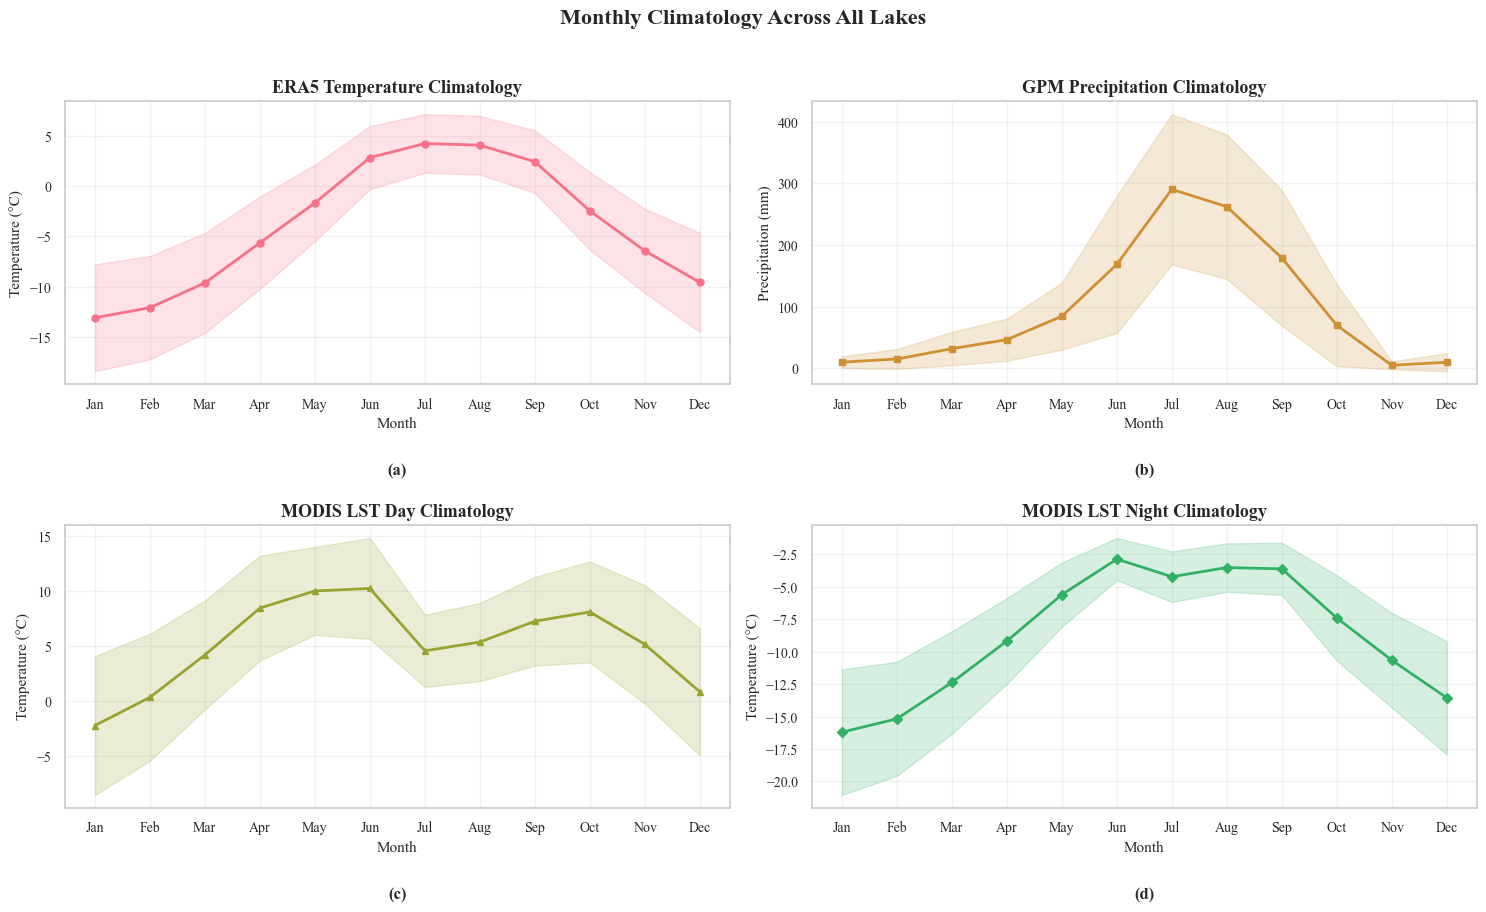

In [9]:
# Monthly climatology: mean +/- std for key variables across all lakes

monthly_clim = df.groupby('month').agg({
    'ERA5_temp_C': ['mean', 'std'],
    'GPM_Precipitation_mm': ['mean', 'std'],
    'LST_Day_C': ['mean', 'std'],
    'LST_Night_C': ['mean', 'std']
}).round(2)

# Month labels
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

month_idx = monthly_clim.index

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# --------------------------------------------------
# ERA5 Temperature
# --------------------------------------------------

temp_mean = df.groupby('month')['ERA5_temp_C'].mean()
temp_std = df.groupby('month')['ERA5_temp_C'].std()

axes[0, 0].plot(
    month_idx,
    temp_mean,
    marker='o',
    markersize=5,
    linewidth=2,
    color=color_palette[0]
)

axes[0, 0].fill_between(
    month_idx,
    temp_mean - temp_std,
    temp_mean + temp_std,
    alpha=0.2,
    color=color_palette[0]
)

axes[0, 0].set_title(
    'ERA5 Temperature Climatology',
    fontsize=13,
    fontweight='bold'
)
axes[0, 0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0, 0].set_xlabel('Month', fontsize=11)
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(month_labels)
axes[0, 0].grid(alpha=0.25)
axes[0, 0].annotate(
    '(a)',
    xy=(0.5, -0.28),
    xycoords='axes fraction',
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold'
)


# --------------------------------------------------
# GPM Precipitation
# --------------------------------------------------

precip_mean = df.groupby('month')['GPM_Precipitation_mm'].mean()
precip_std = df.groupby('month')['GPM_Precipitation_mm'].std()

axes[0, 1].plot(
    month_idx,
    precip_mean,
    marker='s',
    markersize=5,
    linewidth=2,
    color=color_palette[1]
)

axes[0, 1].fill_between(
    month_idx,
    precip_mean - precip_std,
    precip_mean + precip_std,
    alpha=0.2,
    color=color_palette[1]
)

axes[0, 1].set_title(
    'GPM Precipitation Climatology',
    fontsize=13,
    fontweight='bold'
)
axes[0, 1].set_ylabel('Precipitation (mm)', fontsize=11)
axes[0, 1].set_xlabel('Month', fontsize=11)
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_labels)
axes[0, 1].grid(alpha=0.25)
axes[0, 1].annotate(
    '(b)',
    xy=(0.5, -0.28),
    xycoords='axes fraction',
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold'
)


# --------------------------------------------------
# MODIS LST Day
# --------------------------------------------------

lst_day_mean = df.groupby('month')['LST_Day_C'].mean()
lst_day_std = df.groupby('month')['LST_Day_C'].std()

axes[1, 0].plot(
    month_idx,
    lst_day_mean,
    marker='^',
    markersize=5,
    linewidth=2,
    color=color_palette[2]
)

axes[1, 0].fill_between(
    month_idx,
    lst_day_mean - lst_day_std,
    lst_day_mean + lst_day_std,
    alpha=0.2,
    color=color_palette[2]
)

axes[1, 0].set_title(
    'MODIS LST Day Climatology',
    fontsize=13,
    fontweight='bold'
)
axes[1, 0].set_ylabel('Temperature (°C)', fontsize=11)
axes[1, 0].set_xlabel('Month', fontsize=11)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_labels)
axes[1, 0].grid(alpha=0.25)
axes[1, 0].annotate(
    '(c)',
    xy=(0.5, -0.28),
    xycoords='axes fraction',
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold'
)


# --------------------------------------------------
# MODIS LST Night
# --------------------------------------------------

lst_night_mean = df.groupby('month')['LST_Night_C'].mean()
lst_night_std = df.groupby('month')['LST_Night_C'].std()

axes[1, 1].plot(
    month_idx,
    lst_night_mean,
    marker='D',
    markersize=5,
    linewidth=2,
    color=color_palette[3]
)

axes[1, 1].fill_between(
    month_idx,
    lst_night_mean - lst_night_std,
    lst_night_mean + lst_night_std,
    alpha=0.2,
    color=color_palette[3]
)

axes[1, 1].set_title(
    'MODIS LST Night Climatology',
    fontsize=13,
    fontweight='bold'
)
axes[1, 1].set_ylabel('Temperature (°C)', fontsize=11)
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_labels)
axes[1, 1].grid(alpha=0.25)
axes[1, 1].annotate(
    '(d)',
    xy=(0.5, -0.28),
    xycoords='axes fraction',
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold'
)


# --------------------------------------------------
# Final formatting
# --------------------------------------------------

plt.suptitle(
    'Monthly Climatology Across All Lakes',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


Analyzing: Tilicho Lake (GL083851E28690N)
Number of observations: 132


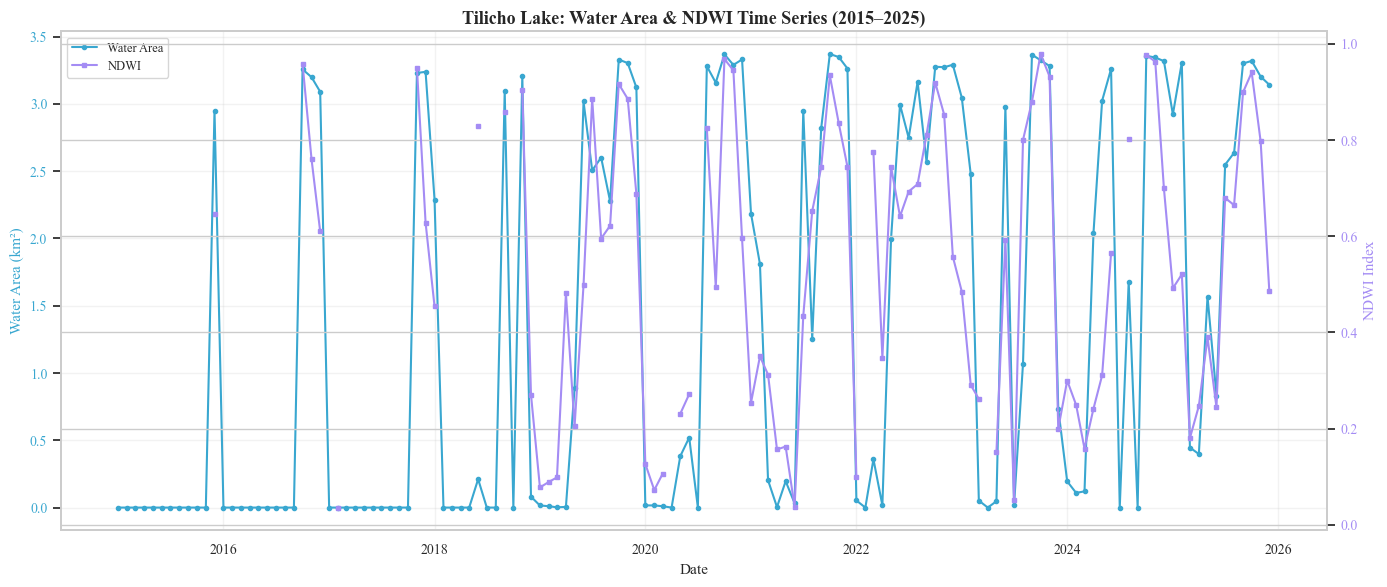


Analyzing: Imja Lake (GL086925E27898N)
Number of observations: 132


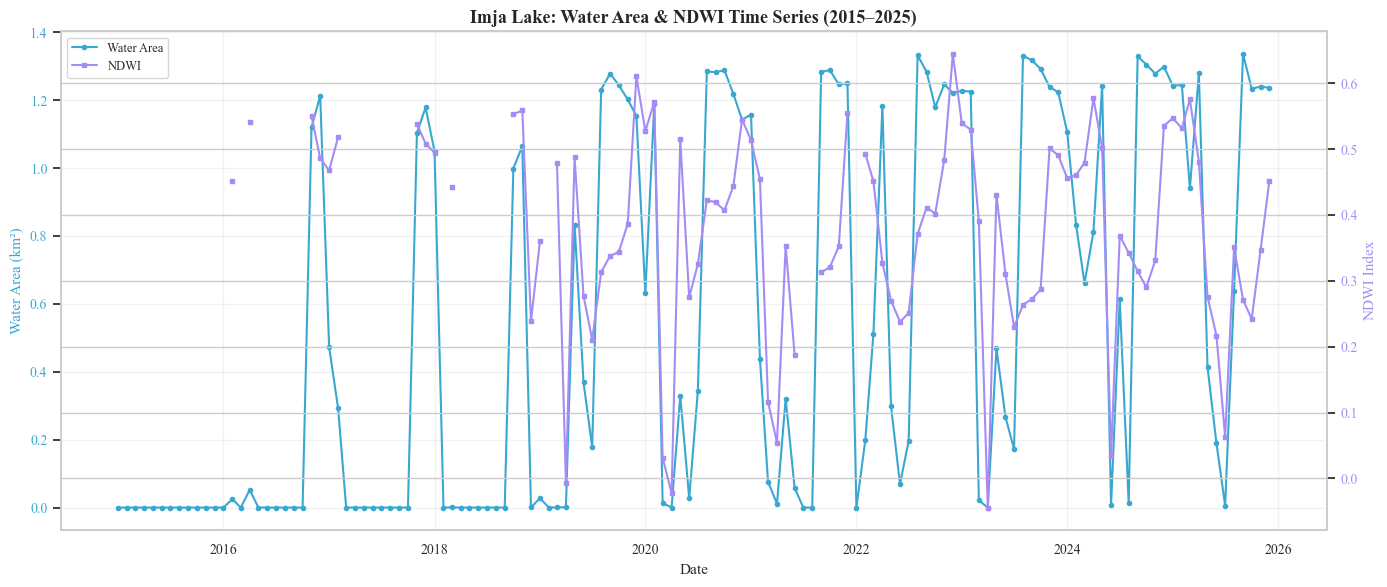


Analyzing: Thulagi Lake (GL084485E28488N)
Number of observations: 132


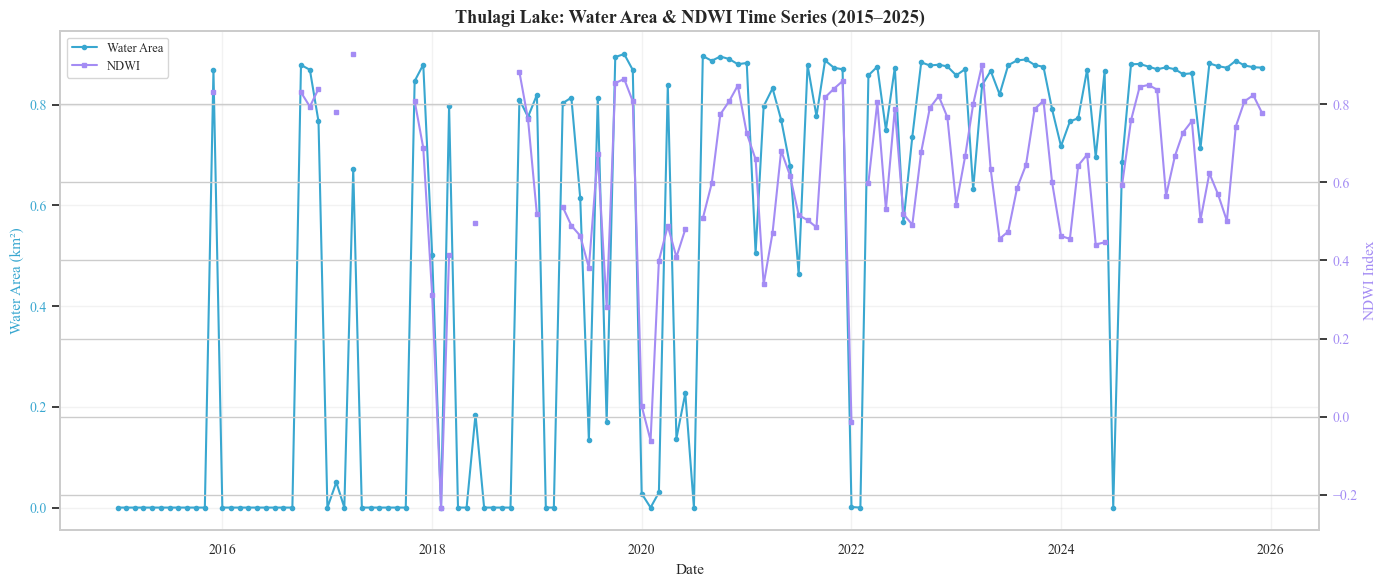

In [10]:
# Select 3 lakes for detailed time series analysis

selected_lakes = {
    'GL083851E28690N': 'Tilicho Lake',
    'GL086925E27898N': 'Imja Lake',
    'GL084485E28488N': 'Thulagi Lake'
}

for lake_id, lake_name in selected_lakes.items():

    print(f"\nAnalyzing: {lake_name} ({lake_id})")

    # Filter and sort data
    lake_data = (
        df[df['GL_ID'] == lake_id]
        .sort_values('date')
    )

    print(f"Number of observations: {len(lake_data)}")

    # Create figure with dual y-axis
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # --------------------------------------------------
    # Water Area — Left Y-axis
    # --------------------------------------------------

    ax1.plot(
        lake_data['date'],
        lake_data['S2_water_area_km2'],
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=color_palette[5],
        label='Water Area'
    )

    ax1.set_xlabel('Date', fontsize=11)
    ax1.set_ylabel(
        'Water Area (km²)',
        fontsize=11,
        color=color_palette[5]
    )

    ax1.tick_params(
        axis='y',
        labelcolor=color_palette[5]
    )

    ax1.grid(alpha=0.25)

    # --------------------------------------------------
    # NDWI — Right Y-axis
    # --------------------------------------------------

    ax2 = ax1.twinx()

    ax2.plot(
        lake_data['date'],
        lake_data['S2_NDWI_mean'],
        marker='s',
        markersize=3,
        linewidth=1.5,
        color=color_palette[6],
        label='NDWI'
    )

    ax2.set_ylabel(
        'NDWI Index',
        fontsize=11,
        color=color_palette[6]
    )

    ax2.tick_params(
        axis='y',
        labelcolor=color_palette[6]
    )

    # --------------------------------------------------
    # Title and legend
    # --------------------------------------------------

    ax1.set_title(
        f'{lake_name}: Water Area & NDWI Time Series (2015–2025)',
        fontsize=13,
        fontweight='bold'
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left',
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

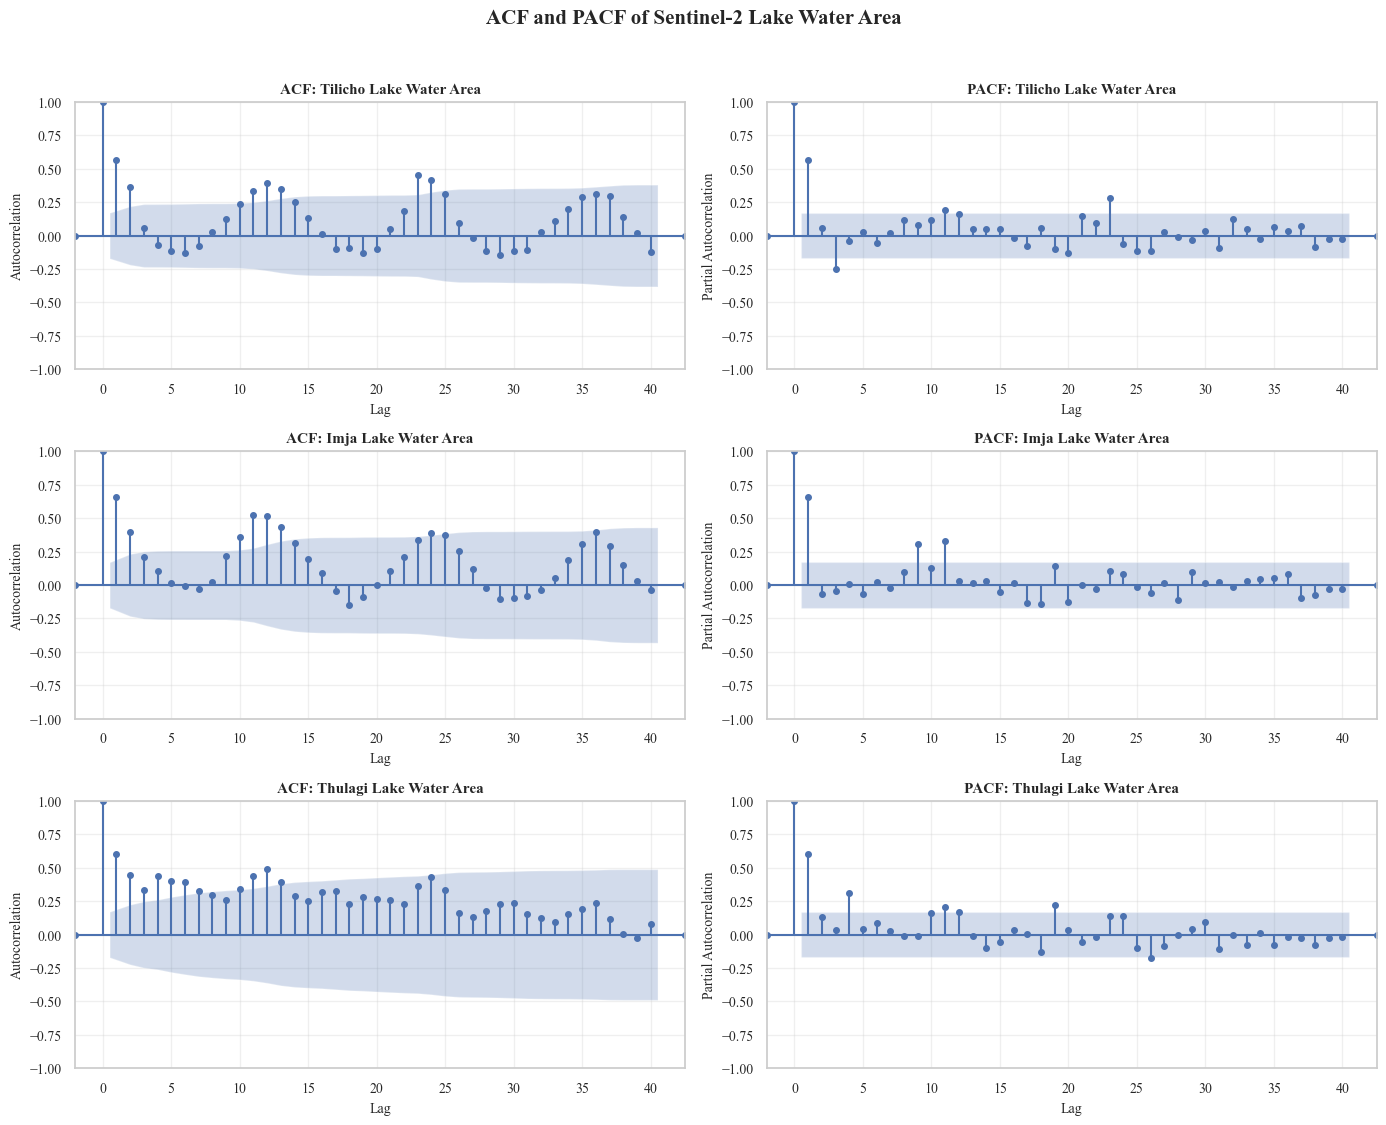

In [11]:
# ACF and PACF plots for 3 selected lakes
# Water-area time series with linear interpolation for missing values

selected_lakes = {
    'GL083851E28690N': 'Tilicho',
    'GL086925E27898N': 'Imja',
    'GL084485E28488N': 'Thulagi'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 11))

for idx, (lake_id, lake_name) in enumerate(selected_lakes.items()):

    # --------------------------------------------------
    # Extract and sort lake water-area time series
    # --------------------------------------------------

    lake_data = (
        df[df['GL_ID'] == lake_id]
        .sort_values('date')
    )

    lake_series = lake_data['S2_water_area_km2'].reset_index(drop=True)

    # Linear interpolation for missing values
    lake_series_filled = (
        lake_series
        .interpolate(method='linear', limit_direction='both')
        .bfill()
        .ffill()
    )

    # --------------------------------------------------
    # ACF
    # --------------------------------------------------

    plot_acf(
        lake_series_filled,
        lags=40,
        ax=axes[idx, 0],
        marker='o',
        markersize=4
    )

    axes[idx, 0].set_title(
        f'ACF: {lake_name} Lake Water Area',
        fontsize=11,
        fontweight='bold'
    )

    axes[idx, 0].set_xlabel('Lag', fontsize=10)
    axes[idx, 0].set_ylabel('Autocorrelation', fontsize=10)
    axes[idx, 0].grid(alpha=0.3)

    # --------------------------------------------------
    # PACF
    # --------------------------------------------------

    plot_pacf(
        lake_series_filled,
        lags=40,
        ax=axes[idx, 1],
        marker='o',
        markersize=4
    )

    axes[idx, 1].set_title(
        f'PACF: {lake_name} Lake Water Area',
        fontsize=11,
        fontweight='bold'
    )

    axes[idx, 1].set_xlabel('Lag', fontsize=10)
    axes[idx, 1].set_ylabel('Partial Autocorrelation', fontsize=10)
    axes[idx, 1].grid(alpha=0.3)


# --------------------------------------------------
# Overall formatting
# --------------------------------------------------

plt.suptitle(
    'ACF and PACF of Sentinel-2 Lake Water Area',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

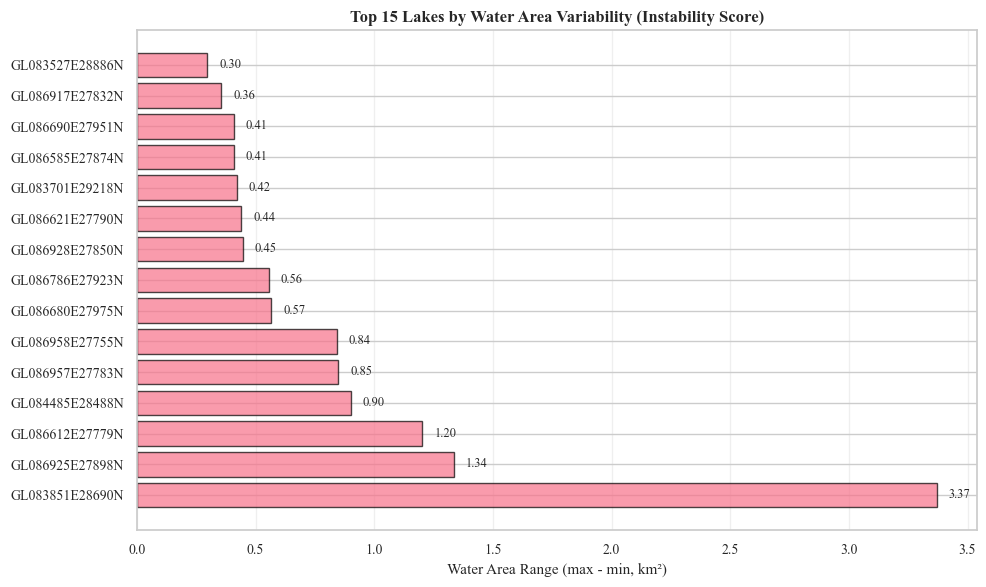

Saved: 11_lake_variability_ranking.png

Top 15 Most Variable Lakes:
                   std  range   mean  count
GL_ID                                      
GL083851E28690N  1.465  3.371  1.363    132
GL086925E27898N  0.562  1.336  0.545    132
GL086612E27779N  0.494  1.202  0.478    132
GL084485E28488N  0.398  0.901  0.516    132
GL086957E27783N  0.342  0.849  0.392    132
GL086958E27755N  0.362  0.841  0.368    132
GL086680E27975N  0.228  0.566  0.248    132
GL086786E27923N  0.228  0.556  0.171    132
GL086928E27850N  0.168  0.445  0.157    132
GL086621E27790N  0.174  0.439  0.163    132
GL083701E29218N  0.167  0.421  0.206    132
GL086585E27874N  0.174  0.408  0.187    132
GL086690E27951N  0.185  0.408  0.229    132
GL086917E27832N  0.121  0.356  0.108    132
GL083527E28886N  0.127  0.296  0.138    132


In [12]:
# Per-lake variability: std and range of S2_water_area_km2
lake_variability = df.groupby('GL_ID')['S2_water_area_km2'].agg([
    ('std', 'std'),
    ('range', lambda x: x.max() - x.min()),
    ('mean', 'mean'),
    ('count', 'count')
]).sort_values('range', ascending=False)

# Top 15 most variable lakes
top_variable = lake_variability.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_variable)), top_variable['range'].values, color=color_palette[0], alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_variable)))
ax.set_yticklabels(top_variable.index, fontsize=10)
ax.set_xlabel('Water Area Range (max - min, km²)', fontsize=11)
ax.set_title('Top 15 Lakes by Water Area Variability (Instability Score)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, val in enumerate(top_variable['range'].values):
    ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / '11_lake_variability_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 11_lake_variability_ranking.png")
print("\nTop 15 Most Variable Lakes:")
print(top_variable.round(3).to_string())

---

## 4. Cross-Sensor Correlation

**Why this matters**: High correlations between sensors reveal redundancy and potential multicollinearity, while low correlations indicate complementary information. This is essential for feature selection and avoiding overfitting in downstream anomaly detection models.

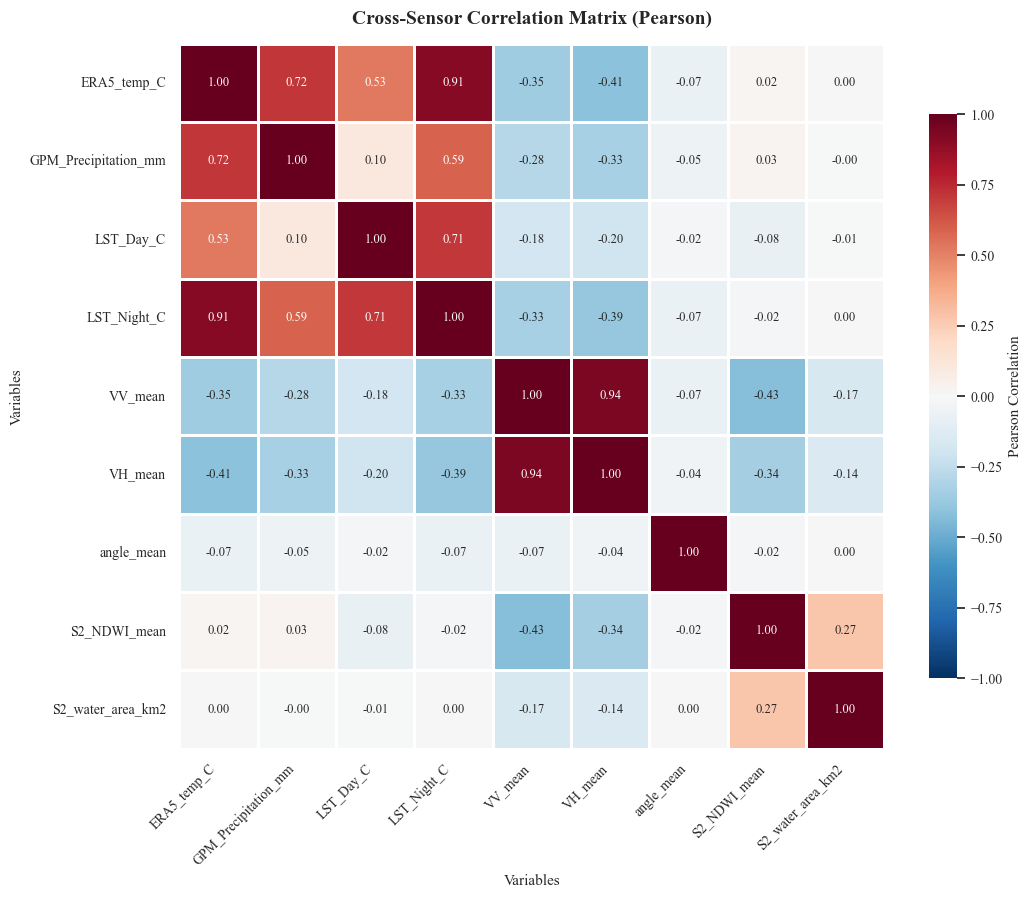

In [13]:
# Correlation heatmap for 9 core sensor variables

sensor_vars = [
    'ERA5_temp_C',
    'GPM_Precipitation_mm',
    'LST_Day_C',
    'LST_Night_C',
    'VV_mean',
    'VH_mean',
    'angle_mean',
    'S2_NDWI_mean',
    'S2_water_area_km2'
]

# Compute Pearson correlation matrix
corr_matrix = df[sensor_vars].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={
        'label': 'Pearson Correlation',
        'shrink': 0.8
    },
    annot_kws={
        'fontsize': 9
    },
    ax=ax
)

# Clean labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

ax.set_xlabel('Variables', fontsize=11)
ax.set_ylabel('Variables', fontsize=11)

ax.set_title(
    'Cross-Sensor Correlation Matrix (Pearson)',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

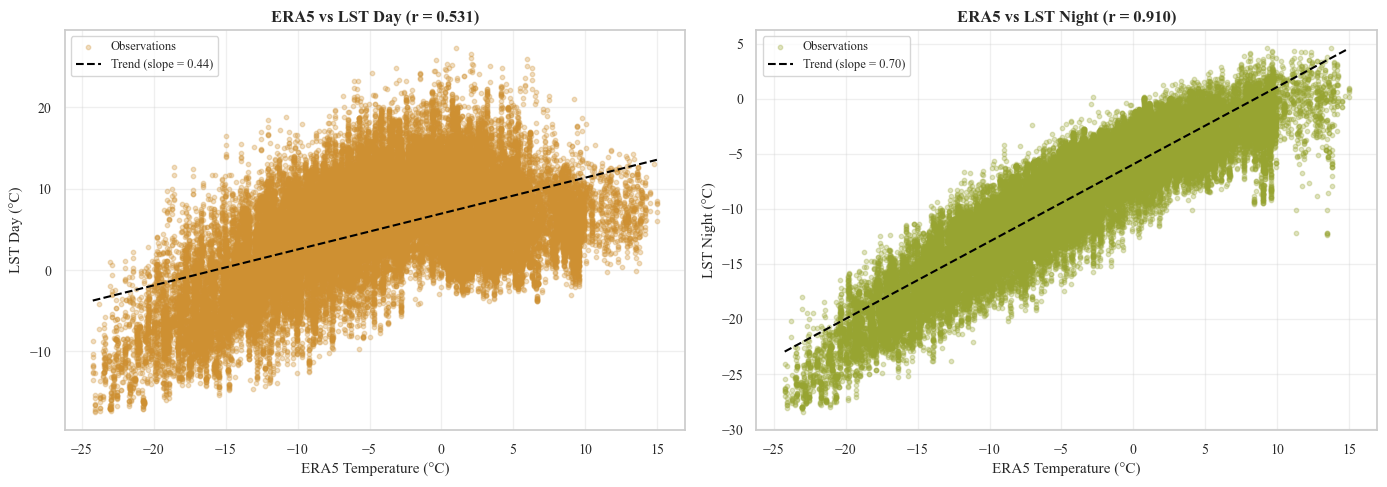

In [14]:
# Scatter plots: Temperature variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ERA5_temp_C vs LST_Day_C
mask_day = df[['ERA5_temp_C', 'LST_Day_C']].notna().all(axis=1)
corr_era5_lst_day = df['ERA5_temp_C'].corr(df['LST_Day_C'])
axes[0].scatter(df['ERA5_temp_C'], df['LST_Day_C'], alpha=0.3, s=10, color=color_palette[1], label='Observations')

z = np.polyfit(df.loc[mask_day, 'ERA5_temp_C'], df.loc[mask_day, 'LST_Day_C'], 1)
x_line = np.linspace(df['ERA5_temp_C'].min(), df['ERA5_temp_C'].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color='black', linewidth=1.5, linestyle='--', label=f'Trend (slope = {z[0]:.2f})')

axes[0].set_xlabel('ERA5 Temperature (°C)', fontsize=11, fontfamily='Times New Roman')
axes[0].set_ylabel('LST Day (°C)', fontsize=11, fontfamily='Times New Roman')
axes[0].set_title(f'ERA5 vs LST Day (r = {corr_era5_lst_day:.3f})', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9, loc='best', frameon=True)

# ERA5_temp_C vs LST_Night_C
mask_night = df[['ERA5_temp_C', 'LST_Night_C']].notna().all(axis=1)
corr_era5_lst_night = df['ERA5_temp_C'].corr(df['LST_Night_C'])
axes[1].scatter(df['ERA5_temp_C'], df['LST_Night_C'], alpha=0.3, s=10, color=color_palette[2], label='Observations')

z2 = np.polyfit(df.loc[mask_night, 'ERA5_temp_C'], df.loc[mask_night, 'LST_Night_C'], 1)
axes[1].plot(x_line, np.poly1d(z2)(x_line), color='black', linewidth=1.5, linestyle='--', label=f'Trend (slope = {z2[0]:.2f})')

axes[1].set_xlabel('ERA5 Temperature (°C)', fontsize=11, fontfamily='Times New Roman')
axes[1].set_ylabel('LST Night (°C)', fontsize=11, fontfamily='Times New Roman')
axes[1].set_title(f'ERA5 vs LST Night (r = {corr_era5_lst_night:.3f})', fontsize=12, fontweight='bold', fontfamily='Times New Roman')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9, loc='best', frameon=True)

plt.tight_layout()
plt.show()

---

## 5. Scan Count / Data Density Sanity Check

**Why this matters**: Scan counts and observation counts track sensor availability and data density. Sudden dips in these metrics can indicate sensor maintenance, orbital adjustments, or data processing issues that need to be accounted for when interpreting anomalies.

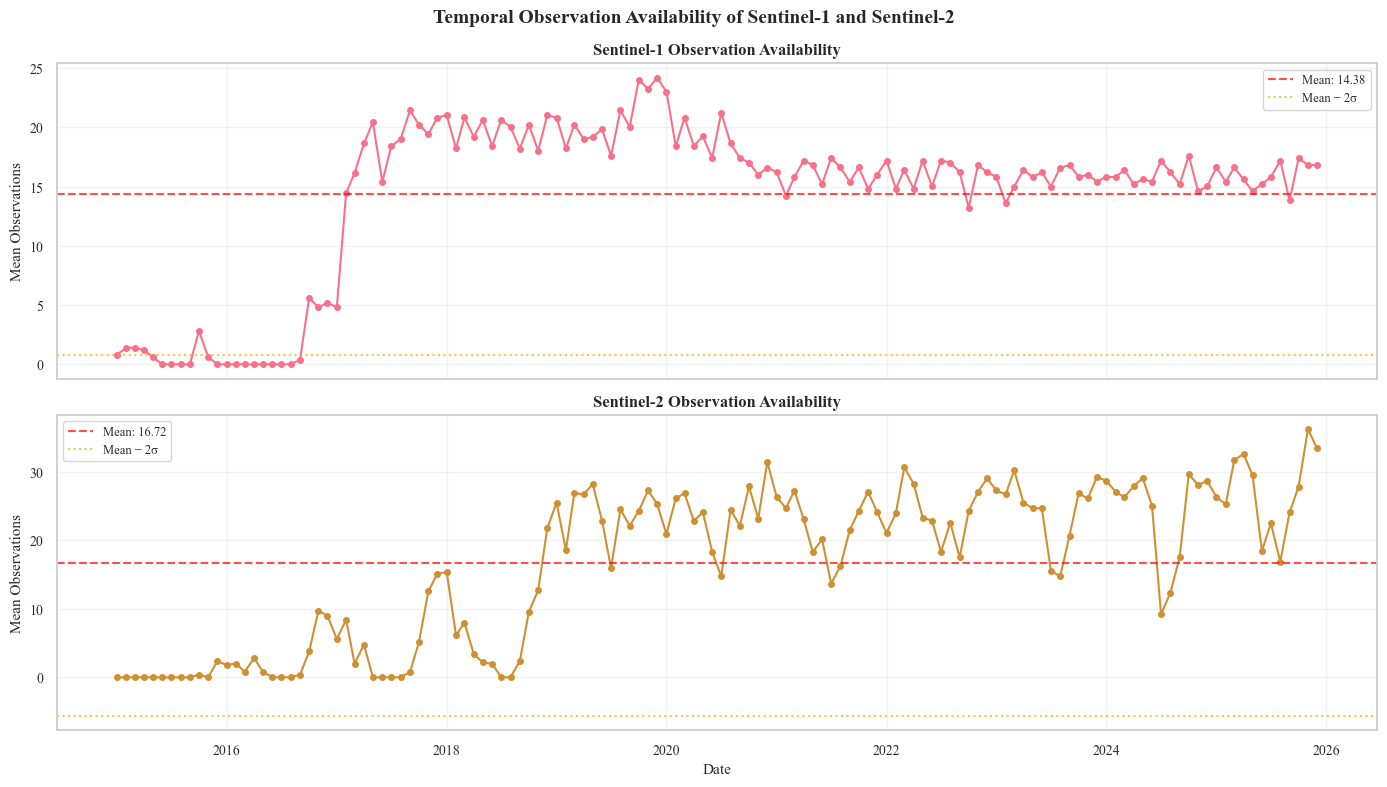

In [15]:
# Sentinel-1 and Sentinel-2 observation density over time

observation_density = df.groupby('date').agg({
    'S1_observations': 'mean',
    'S2_observations': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

observation_vars = [
    'S1_observations',
    'S2_observations'
]

titles = [
    'Sentinel-1 Observation Availability',
    'Sentinel-2 Observation Availability'
]

for idx, (var, title) in enumerate(zip(observation_vars, titles)):

    ax = axes[idx]

    mean_val = observation_density[var].mean()
    std_val = observation_density[var].std()

    # Observation series
    ax.plot(
        observation_density['date'],
        observation_density[var],
        marker='o',
        markersize=4,
        linewidth=1.5,
        color=color_palette[idx]
    )

    # Mean
    ax.axhline(
        mean_val,
        color='red',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        label=f'Mean: {mean_val:.2f}'
    )

    # Low-observation threshold
    ax.axhline(
        mean_val - 2 * std_val,
        color='orange',
        linestyle=':',
        linewidth=1.5,
        alpha=0.7,
        label='Mean − 2σ'
    )

    ax.set_ylabel(
        'Mean Observations',
        fontsize=11
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight='bold'
    )

    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

axes[1].set_xlabel('Date', fontsize=11)

plt.suptitle(
    'Temporal Observation Availability of Sentinel-1 and Sentinel-2',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---

## 6. Lake-Level Risk Proxies: Size, Growth & Extreme Events

**Why this matters**: Static lake size alone does not predict GLOF hazard — a small lake expanding rapidly can pose more immediate risk than a large, stable one. This section separates "biggest" from "fastest-changing," and flags candidate rapid-expansion events using a naive threshold approach. Both serve as sanity-check baselines against which the Stage 1 LSTM-Autoencoder's learned, multi-feature anomaly scores can later be compared.

### 6.2 Biggest vs. Fastest-Growing Lakes (Size ≠ Risk)


BIGGEST LAKES vs. FASTEST-GROWING LAKES

Lakes with valid trend fit (n >= 12 months): 494 / 494
Lakes excluded from growth/shrink ranking (mean area <= 0.01 km²): 391
Lakes eligible for growth/shrink ranking: 103
Lakes appearing in BOTH top-10-by-size and top-10-by-growth-rate: 9 / 10
['GL083851E28690N', 'GL084485E28488N', 'GL086585E27874N', 'GL086612E27779N', 'GL086680E27975N', 'GL086690E27951N', 'GL086925E27898N', 'GL086957E27783N', 'GL086958E27755N']


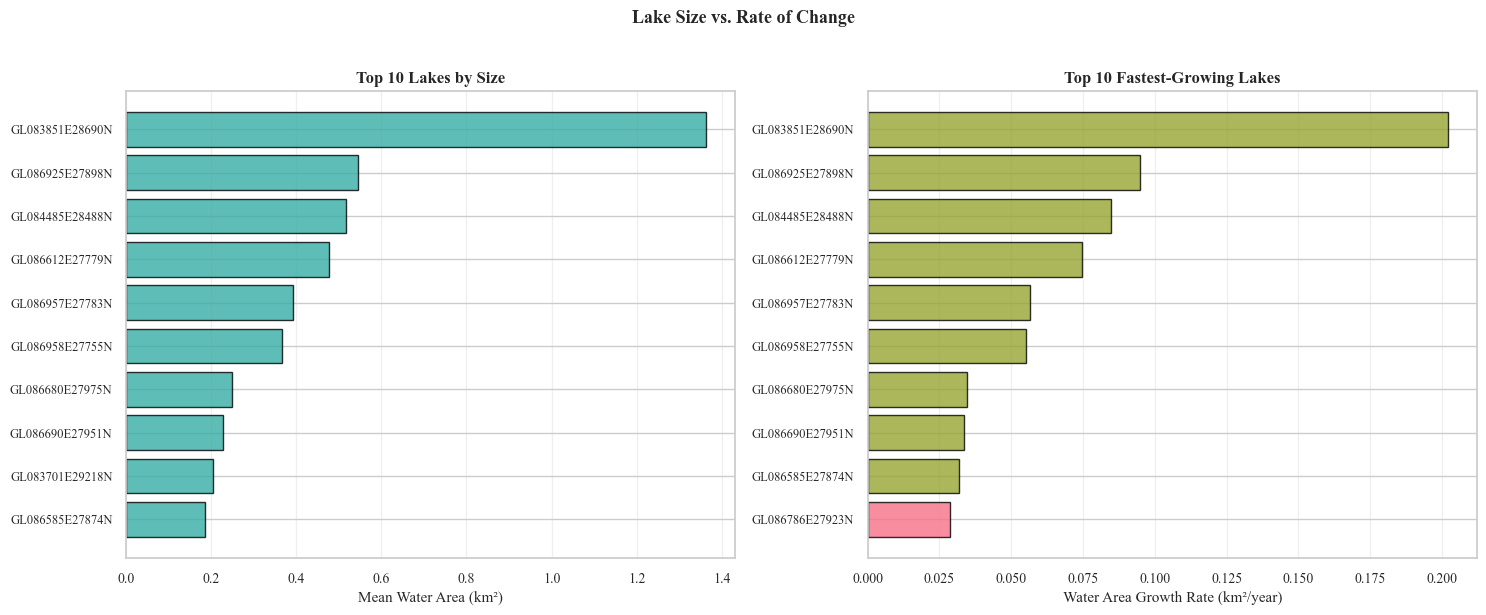

Saved: 16_size_vs_growth_comparison.png

Top 10 Fastest-Growing Lakes (linear trend, km²/year, mean area > 0.01 km²):
                 mean_area_km2  slope_km2_per_year  pct_change_per_year  n_obs
GL_ID                                                                         
GL083851E28690N         1.3633              0.2021              14.8211    132
GL086925E27898N         0.5452              0.0950              17.4158    132
GL084485E28488N         0.5163              0.0849              16.4448    132
GL086612E27779N         0.4783              0.0747              15.6066    132
GL086957E27783N         0.3923              0.0564              14.3733    132
GL086958E27755N         0.3677              0.0551              14.9842    132
GL086680E27975N         0.2484              0.0347              13.9534    132
GL086690E27951N         0.2288              0.0334              14.5977    132
GL086585E27874N         0.1871              0.0320              17.0850    132
GL086786E2792

In [16]:
# Linear trend (slope) of S2_water_area_km2 per lake, in km²/year
# Using the actual multi-sensor time series (not the static ICIMOD inventory area)
df['years_since_start'] = (df['date'] - df['date'].min()).dt.days / 365.25

MIN_OBS = 12       # require at least ~1 year of valid water-area readings to fit a trend
MIN_AREA_KM2 = 0.01  # exclude near-empty/noise lakes (<1 hectare mean area) from growth/shrink ranking

trend_records = []
for gl_id, g in df.groupby('GL_ID'):
    g = g.dropna(subset=['S2_water_area_km2'])
    if len(g) < MIN_OBS:
        continue
    x = g['years_since_start'].values
    y = g['S2_water_area_km2'].values
    slope, intercept = np.polyfit(x, y, 1)
    mean_area = y.mean()
    pct_change_per_year = (slope / mean_area * 100) if mean_area > 0 else np.nan
    trend_records.append({
        'GL_ID': gl_id,
        'mean_area_km2': mean_area,
        'slope_km2_per_year': slope,
        'pct_change_per_year': pct_change_per_year,
        'n_obs': len(g)
    })

lake_trends = pd.DataFrame(trend_records).set_index('GL_ID')

# Filter out near-empty lakes before ranking growth/shrink — below this size,
# NDWI-based water detection is noisy and slope/pct_change become numerical artifacts
# rather than real signal (a few m² of measurement noise can look like "17% growth").
n_excluded = (lake_trends['mean_area_km2'] <= MIN_AREA_KM2).sum()
lake_trends_ranked = lake_trends[lake_trends['mean_area_km2'] > MIN_AREA_KM2]

top10_by_size = lake_trends.sort_values('mean_area_km2', ascending=False).head(10)
top10_by_growth = lake_trends_ranked.sort_values('slope_km2_per_year', ascending=False).head(10)
top10_by_shrink = lake_trends_ranked.sort_values('slope_km2_per_year', ascending=True).head(10)

overlap = set(top10_by_size.index) & set(top10_by_growth.index)

print("\n" + "="*70)
print("BIGGEST LAKES vs. FASTEST-GROWING LAKES")
print("="*70)
print(f"\nLakes with valid trend fit (n >= {MIN_OBS} months): {len(lake_trends)} / {df['GL_ID'].nunique()}")
print(f"Lakes excluded from growth/shrink ranking (mean area <= {MIN_AREA_KM2} km²): {n_excluded}")
print(f"Lakes eligible for growth/shrink ranking: {len(lake_trends_ranked)}")
print(f"Lakes appearing in BOTH top-10-by-size and top-10-by-growth-rate: {len(overlap)} / 10")
if overlap:
    print(sorted(overlap))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(range(len(top10_by_size)), top10_by_size['mean_area_km2'].values,
             color=color_palette[4], alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(len(top10_by_size)))
axes[0].set_yticklabels(top10_by_size.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean Water Area (km²)', fontsize=11)
axes[0].set_title('Top 10 Lakes by Size', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

colors_growth = [color_palette[2] if gl in overlap else color_palette[0] for gl in top10_by_growth.index]
axes[1].barh(range(len(top10_by_growth)), top10_by_growth['slope_km2_per_year'].values,
             color=colors_growth, alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(top10_by_growth)))
axes[1].set_yticklabels(top10_by_growth.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Water Area Growth Rate (km²/year)', fontsize=11)
axes[1].set_title('Top 10 Fastest-Growing Lakes', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Lake Size vs. Rate of Change', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_dir / '16_size_vs_growth_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 16_size_vs_growth_comparison.png")

print("\nTop 10 Fastest-Growing Lakes (linear trend, km²/year, mean area > "
      f"{MIN_AREA_KM2} km²):")
print(top10_by_growth[['mean_area_km2', 'slope_km2_per_year', 'pct_change_per_year', 'n_obs']].round(4).to_string())

print("\nTop 10 Fastest-Shrinking Lakes (linear trend, km²/year, mean area > "
      f"{MIN_AREA_KM2} km²):")
print(top10_by_shrink[['mean_area_km2', 'slope_km2_per_year', 'pct_change_per_year', 'n_obs']].round(4).to_string())

### 6.3 Extreme Month-over-Month Water Area Jumps

## 7. Summary & Key Findings

### Missingness Mechanism & Seasonality

**Findings to complete after review:**

- **S2_NDWI_mean (~47% missing):**  
  - [ ] Document peak missingness month (monsoon?)  
  - [ ] Correlation between cloud cover and S2_observations = 0  
  - [ ] Implications for imputation strategy (e.g., forward-fill during monsoon windows)  

- **Sentinel-1 SAR (~12.6% missing):**  
  - [ ] Revisit cycle gaps or orbital discontinuities?  
  - [ ] Temporal or spatial patterns?  
  - [ ] Can SAR gaps be predictable (e.g., fixed orbital pattern)?  

### Data Quality Issues

- [ ] Any physically implausible values detected? (NDWI outside [−1, 1], negative precipitation, etc.)  
- [ ] Outliers in SAR backscatter or water area measurements?  
- [ ] Consistency check result: S2_observations = 0 ↔ S2_NDWI_mean null — % match?  

### Seasonal & Temporal Patterns

- [ ] Strong monsoon cycle in GPM precipitation (June–September peak)?  
- [ ] Temperature cycles (ERA5 vs LST) — are they aligned?  
- [ ] Water area temporal patterns — do they correlate with temperature/precipitation?  
- [ ] Most unstable (variable) lakes — geographic clusters or random?  

### Cross-Sensor Relationships

- [ ] High correlations between ERA5_temp_C and LST (day/night)?  
  - Implication: Potential redundancy; consider dropping one in autoencoder  
- [ ] SAR backscatter (VV/VH) — correlation with water area?  
  - Implication: SAR provides independent signal for water dynamics  
- [ ] VV–VH ratio — meaningful proxy for surface roughness/water properties?  

### Preprocessing Strategy for Autoencoder

- [ ] **Imputation approach for S2_NDWI (47% missing):**  
  - Forward-fill during monsoon gaps (known missing window)?  
  - Interpolate from seasonal climatology?  
  - Leave as missing (mask in autoencoder)?  

- [ ] **Imputation for SAR (~12.6% missing):**  
  - Interpolation across time?  
  - Spatial nearest-neighbor from nearby lakes?  

- [ ] **Feature scaling:**  
  - Normalize/standardize all continuous variables before autoencoder?  
  - Handle outliers (winsorization or removal)?  

- [ ] **Feature selection:**  
  - Drop ERA5_temp_C if LST_Day_C is highly correlated?  
  - Keep derived VV–VH_ratio as new feature?  

### Lake-Level Risk Proxies

- [ ] Do the top-10-by-size and top-10-by-growth-rate lake lists diverge? By how much?  
- [ ] Which districts/basins do the fastest-growing lakes cluster in?  
- [ ] How many extreme month-over-month jump events were flagged, and do they cluster in particular years or seasons (e.g., post-monsoon)?  
- [ ] Do any flagged extreme-jump lakes overlap with the Adhikari et al. (2025) focus lakes?  

### Next Steps

1. Document final conclusions for each section above.  
2. Finalize imputation and normalization pipeline in a dedicated preprocessing module.  
3. Prepare cleaned, normalized dataset for LSTM Autoencoder training.  
4. Reserve holdout lakes for validation of learned anomalies.